<a href="https://colab.research.google.com/github/Clinton1029/Heart_Failure/blob/main/Heart_Failure1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction Using Machine Learning

## Introduction

Heart disease is one of the leading causes of death worldwide. Early detection can help healthcare professionals provide timely treatment and improve patient outcomes.

Machine learning enables computers to learn patterns from clinical data and predict whether a patient is likely to have heart disease. In this project, a Random Forest classifier is developed using patient attributes such as age, chest pain type, cholesterol level, blood pressure, and maximum heart rate to predict the presence of heart disease.

The performance of the model is evaluated and further improved through hyperparameter tuning using Random Search and Grid Search.

## Problem Statement

Diagnosing heart disease can be challenging because it depends on several clinical factors, including age, blood pressure, cholesterol level, chest pain type, and heart rate. An accurate prediction model can assist healthcare professionals in identifying patients at risk and support early diagnosis and treatment.

This project aims to develop and evaluate a machine learning model that predicts the presence of heart disease using patients' clinical data.

# Project Workflow

The project will follow these steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Preparation
5. Feature Selection
6. Split the Dataset into Training and Testing Sets
7. Choose the Machine Learning Model
8. Train the Machine Learning Model
9. Make Predictions
10. Evaluate Model Performance
11. Hyperparameter Tuning

12. Predict Heart Failure Outcome for New Patients

## 1. Import Required Libraries


In [45]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


## 2. Load the Dataset

In [3]:
# Fetch the Heart Failure dataset

heart= fetch_openml(data_id=43682, as_frame=True)

df = heart.frame

# Convert to a pandas DataFrame
df = heart.frame

# Display the first five rows
df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Display the First Five Rows


In [4]:
df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


### 3.2 Display the Last Five Rows


In [5]:
df.tail()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
1185,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,1.0
1186,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,1.0
1187,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0
1188,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0
1189,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0


### 3.3 Dataset Dimensions


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1190, 12)


### 3.4 Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  ST_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


### 3.5 Summary Statistics

In [8]:
df.describe()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


### 3.5 Check Missing Values


In [9]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp_s,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_angina,0
oldpeak,0


###### There is no missing values

### 3.6 Check Duplicate Records

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 272


###### There are 272 Duplicated rows and Therefore Data cleaning is required to remove Duplicate

### 3.8 Distribution of the Target Variable

The target variable represents whether a patient has heart disease. Examining its distribution helps determine whether the dataset is balanced or imbalanced.

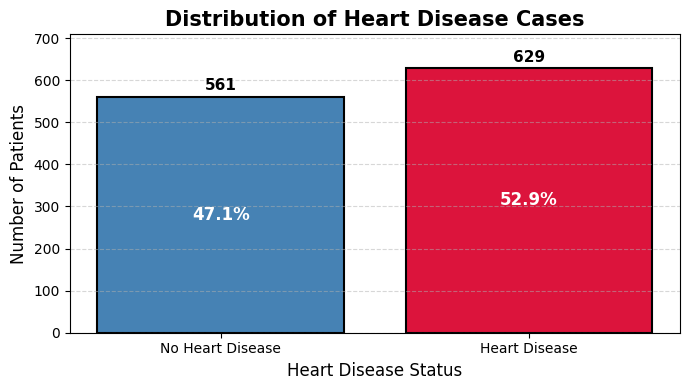

In [11]:


# Count target classes
target_counts = df["target"].value_counts().sort_index()
total = len(df)

# Create figure
plt.figure(figsize=(7, 4))

# Create bars
bars = plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts,
    color=["steelblue", "crimson"],
    edgecolor="black",
    linewidth=1.5
)

# Add labels
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100

    # Percentage inside the bar
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,
        f"{percentage:.1f}%",
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

    # Count above the bar
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 8,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

# Customize the plot
plt.title("Distribution of Heart Disease Cases", fontsize=15, fontweight='bold')
plt.xlabel("Heart Disease Status", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add some space above the bars
plt.ylim(0, max(target_counts) + 80)

# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###### Interpretation of the Target Variable Distribution

The distribution of the target variable indicates that the dataset contains patients from both classes. Specifically, **629 patients were diagnosed with heart disease**, while **561 patients did not have heart disease**. This shows that the dataset is relatively balanced, with only a slight difference between the two classes.


### 3.9 Distribution of Numerical Features

Histograms are used to visualize the distribution of numerical variables. They help determine whether the data is normally distributed, skewed, or contains potential outliers.

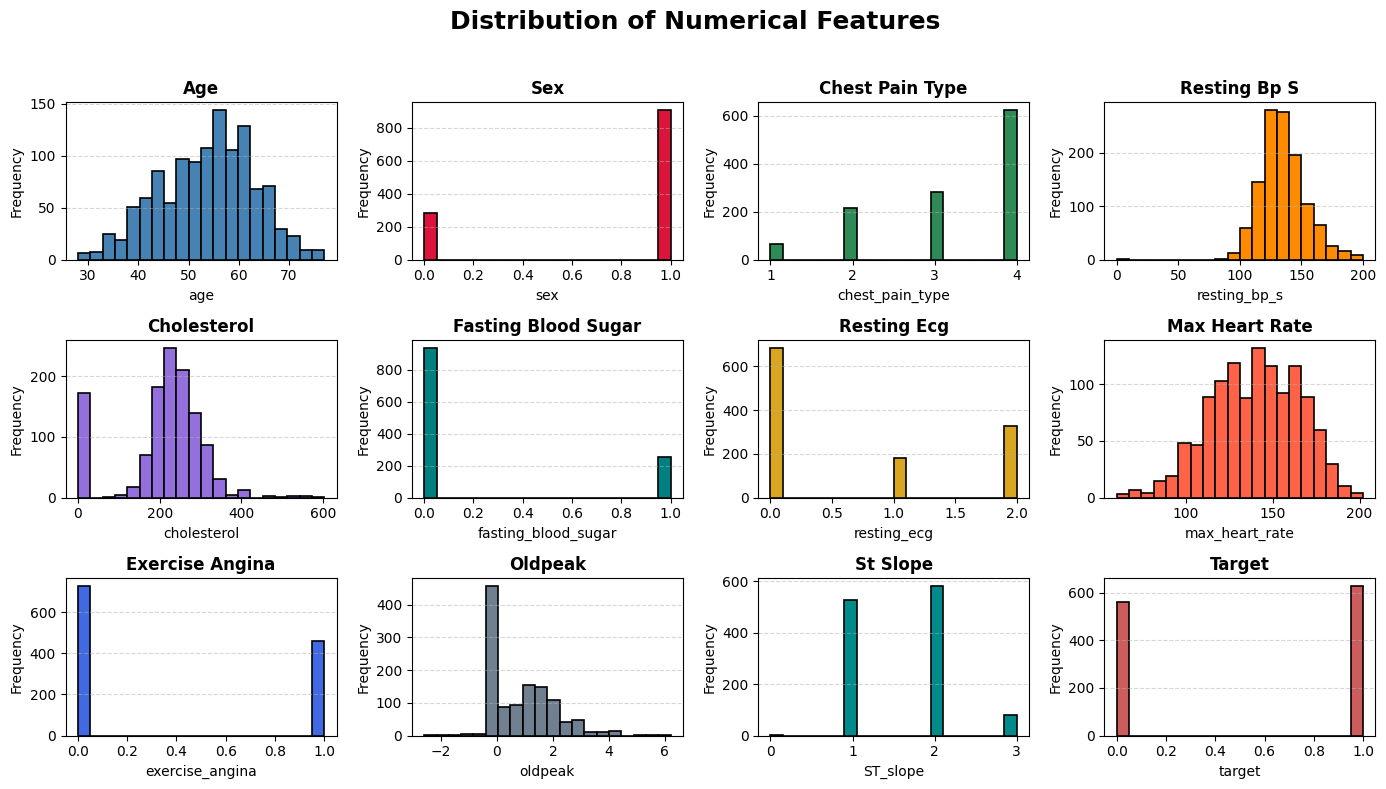

In [12]:


# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create subplots
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

# Colors to cycle through
colors = [
    "steelblue", "crimson", "seagreen", "darkorange",
    "mediumpurple", "teal", "goldenrod", "tomato",
    "royalblue", "slategray", "darkcyan", "indianred"
]

# Plot histograms
for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df[col],
        bins=20,
        color=colors[i % len(colors)],
        edgecolor="black",
        linewidth=1.2
    )

    axes[i].set_title(col.replace("_", " ").title(),
                      fontsize=12,
                      fontweight="bold")

    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Remove unused subplot (if any)
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

###### Interpretation of the Distribution of Numerical Features

- **Age:** Most patients are between **45 and 60 years**, indicating that heart disease is more common among middle-aged and older adults.
- **Sex:** The dataset contains more **male** patients than female patients.
- **Chest Pain Type:** **Asymptomatic chest pain (Type 4)** is the most common category.
- **Resting Blood Pressure:** Most values range between **110 and 150 mmHg**, with a few possible outliers.
- **Cholesterol:** Cholesterol levels are mostly between **180 and 300 mg/dL**, with a right-skewed distribution.
- **Fasting Blood Sugar:** Most patients have **normal fasting blood sugar**.
- **Resting ECG:** The majority of patients have **normal ECG results**.
- **Maximum Heart Rate:** The values are approximately normally distributed, with most patients between **120 and 170 bpm**.
- **Exercise-Induced Angina:** More patients **do not experience exercise-induced angina** than those who do.
- **Oldpeak:** Most values are close to **0**, with relatively few high values.
- **ST Slope:** Categories **1 and 2** are more common than category **3**.
- **Target:** The dataset is **fairly balanced**, making it suitable for building a reliable classification model.

### 3.10 Outlier Detection

Boxplots are used to identify potential outliers in numerical variables. Outliers may significantly influence the performance of certain machine learning algorithms and should be investigated before model training.

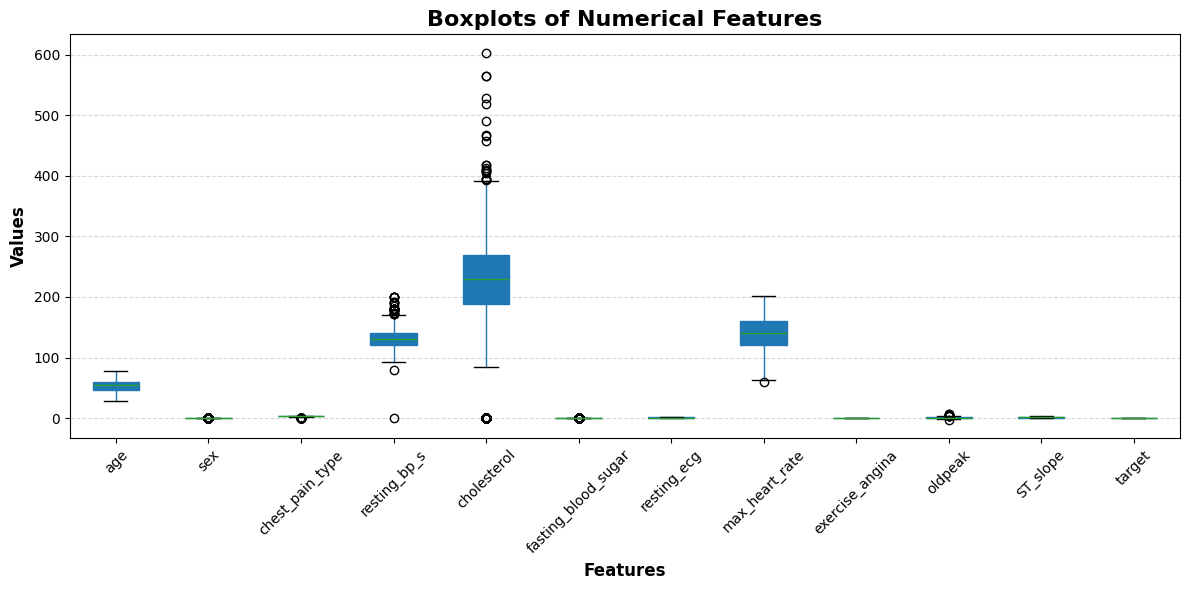

In [13]:


plt.figure(figsize=(12, 6))

box = df.boxplot(
    patch_artist=True,
    rot=45,
    grid=False,
    fontsize=10
)

# Color all boxplots
colors = [
    "steelblue", "crimson", "seagreen", "darkorange",
    "mediumpurple", "teal", "goldenrod", "tomato",
    "royalblue", "slategray", "darkcyan", "indianred"
]

for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title(
    "Boxplots of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Values",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

###### Interpretation of the Boxplots

The boxplots show that most variables have a reasonable spread with a few potential outliers.

**Cholesterol** exhibits the highest number of outliers, indicating that some patients have unusually high cholesterol levels.

 **Resting Blood Pressure**, **Maximum Heart Rate**, and **Oldpeak** also contain a few outliers.

  In contrast, binary variables such as **Sex**, **Fasting Blood Sugar**, **Exercise-Induced Angina**, and **Target** show little variation because they consist of only two categories.

Overall, the dataset contains some extreme values that may require consideration during the data preprocessing stage.

### 3.9 Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. A correlation heatmap provides a visual representation of these relationships and helps identify features that are strongly associated with the target variable.

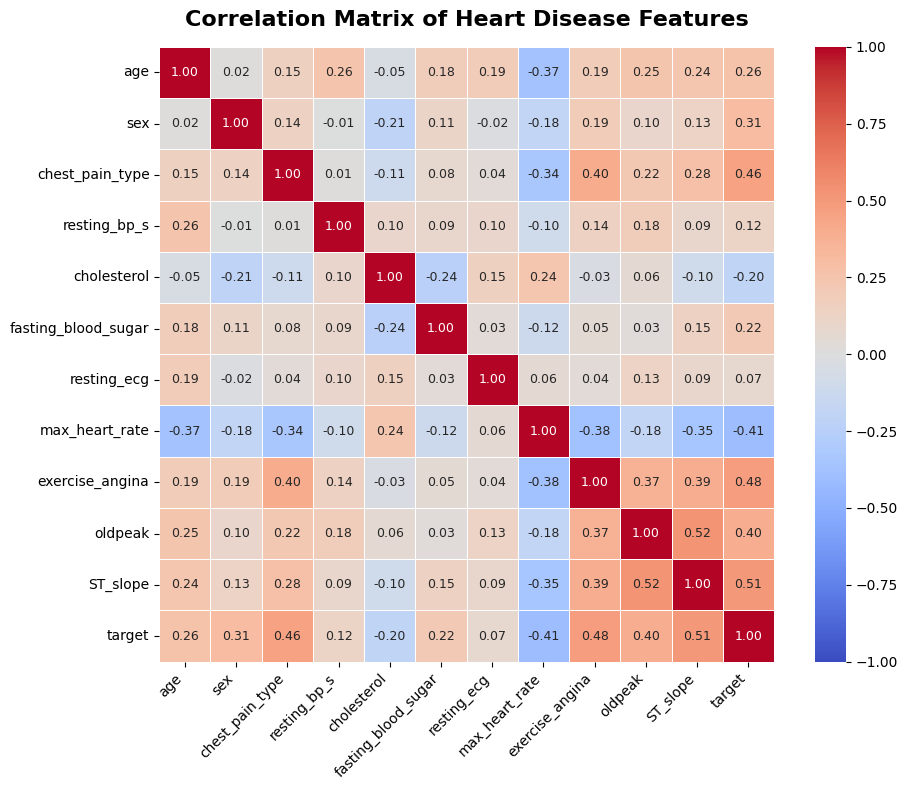

In [14]:


# Compute correlation matrix
corr_matrix = df.corr()

# Create figure
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size": 9},
    vmin=-1,
    vmax=1,
    center=0
)

# Customize plot
plt.title(
    "Correlation Matrix of Heart Disease Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

###### Interpretation of the Correlation Matrix

The correlation matrix shows that most variables have **weak to moderate correlations**, indicating that they provide unique information for predicting heart disease.

The **target** variable has the strongest positive correlations with **ST Slope (0.51)**, **Exercise-Induced Angina (0.48)**, **Chest Pain Type (0.46)**, and **Oldpeak (0.40)**, suggesting that these are important predictors of heart disease.

 In contrast, **Maximum Heart Rate (-0.41)** has the strongest negative correlation with the target, indicating that higher maximum heart rates are generally associated with a lower likelihood of heart disease.

  Overall, the absence of very strong correlations among the predictor variables suggests that multicollinearity is not a major concern in this dataset.

## 4 Data Preprocessing and Preparation

### 4.1 Checking Missing Values

In [15]:
# Check missing values
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp_s,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_angina,0
oldpeak,0


###### There is no missing values

### 4.2 Check Duplicate Records

In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 272


###### There are 272 Duplicated rows and Therefore Data cleaning is required to remove Duplicate

#### 4.2.1 Handle Duplicate Records

In [17]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Verify
print("New dataset shape:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

New dataset shape: (918, 12)
Remaining duplicates: 0


######  Absence of Duplicates after removing

### 4.3 Detecting Outliers using the Interquartile Range (IQR) method

In [18]:
# Select continuous variables
continuous_cols = [
    'age',
    'resting_bp_s',
    'cholesterol',
    'max_heart_rate',
    'oldpeak'
]

# Count outliers using the IQR method
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

age: 0 outliers
resting_bp_s: 28 outliers
cholesterol: 183 outliers
max_heart_rate: 2 outliers
oldpeak: 16 outliers


######Interpretation of Outlier Detection

The Interquartile Range (IQR) method was used to identify potential outliers in the continuous variables.

The results showed that **Age** contained no outliers, indicating a consistent age distribution among the patients.

**Resting Blood Pressure** had **28** outliers, while **Maximum Heart Rate** and **Oldpeak** had **2** and **16** outliers, respectively.

The highest number of outliers was observed in **Cholesterol**, with **183** potential outliers.



### 4.3.1  Handle Outliers by Capping

Since these extreme values are likely to represent genuine medical conditions rather than data entry errors, the outliers were **capped using the IQR method** instead of being removed.

This approach minimizes the influence of extreme values while preserving all patient records for model training.

It retains clinically meaningful observations that may be important for predicting heart disease.

In [19]:
# Cap outliers using the IQR method
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers have been capped successfully.")

Outliers have been capped successfully.


### 4.3.2 Verify with Boxplots

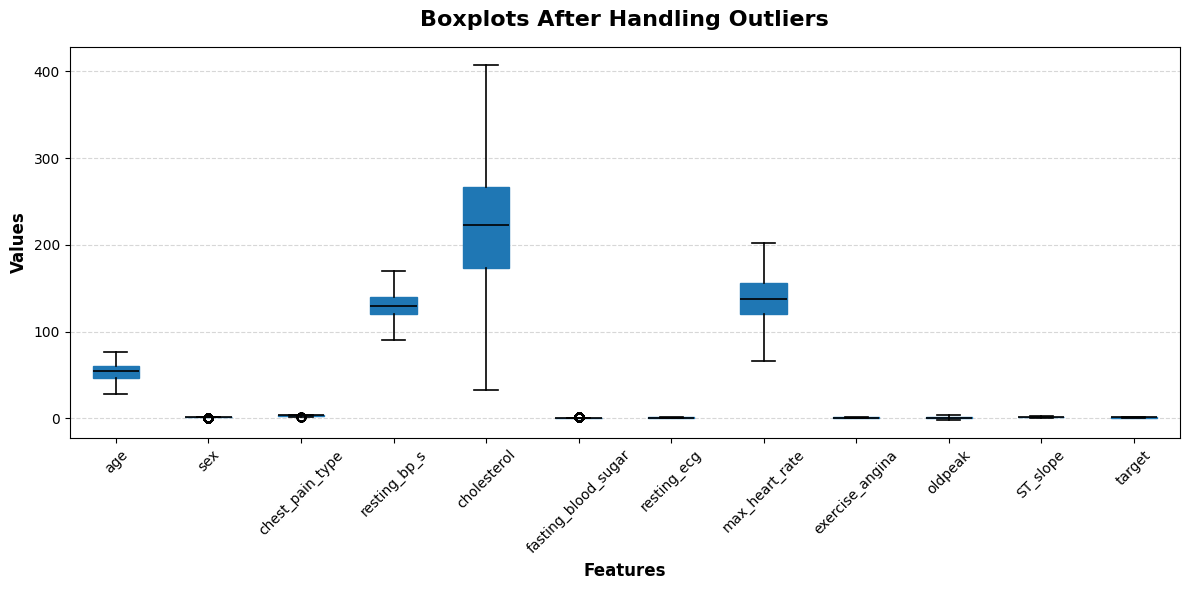

In [20]:

plt.figure(figsize=(12, 6))

# Create boxplots
box = df.boxplot(
    patch_artist=True,
    rot=45,
    grid=False,
    fontsize=10
)

# Colors for each feature
colors = [
    "steelblue", "crimson", "seagreen", "darkorange",
    "mediumpurple", "teal", "goldenrod", "tomato",
    "royalblue", "slategray", "darkcyan", "indianred"
]

# Apply colors to the boxes
for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_alpha(0.8)

# Customize whiskers, caps, medians and fliers
for line in box.lines:
    line.set_color("black")
    line.set_linewidth(1.2)

# Titles and labels
plt.title(
    "Boxplots After Handling Outliers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Values",
    fontsize=12,
    fontweight="bold"
)

# Add horizontal grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Feature Selection

Feature selection is the process of identifying the most relevant predictor variables for a machine learning model. It helps improve model performance by reducing irrelevant or redundant features, decreasing computational complexity, and enhancing model interpretability.

In this project, feature selection is performed to determine which clinical variables have the greatest influence on predicting heart disease. The selected features will then be used to train the machine learning models.

### 5.1 Define the Features and Target Variable

The predictor variables (X) and the target variable (y) are separated to prepare the dataset for feature selection.

#### 5.1.1   Features (x)

In [21]:
# Define the predictor variables (features)
X = df[['age',
        'sex',
        'chest_pain_type',
        'resting_bp_s',
        'cholesterol',
        'fasting_blood_sugar',
        'resting_ecg',
        'max_heart_rate',
        'exercise_angina',
        'oldpeak',
        'ST_slope']]

# Display the first five rows
X.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0


#### 5.1.1   Target (Y)

In [22]:
# Define The target variable
y = df["target"]

# Display the first five rows
y.head()

,target
0,0.0
1,1.0
2,0.0
3,1.0
4,0.0


## 6. Split the Dataset into Training and Testing Sets


Splitting the dataset into training and testing sets is an essential step in machine learning. The training set is used to train the model by allowing it to learn patterns from the data, while the testing set is used to evaluate the model's performance on unseen data. This helps determine how well the model generalizes to new observations.

In this project, **80%** of the dataset is allocated for training and **20%** for testing.

In [69]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,

)

#### 6.1 Verify the Split

The dimensions of the training and testing sets are displayed to confirm that the dataset has been split correctly.

In [70]:
print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)

Training Features (X_train): (734, 11)
Testing Features (X_test): (184, 11)
Training Target (y_train): (734,)
Testing Target (y_test): (184,)


## 7. Choose the Machine Learning Model

In [71]:
# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

## 8. Train the Machine Learning Model

In [72]:
# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Step 9. Make Predictions

After training, the model is used to predict the heart disease status of patients in the testing dataset.

In [73]:
# Make predictions
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[0. 1. 1. 1. 0. 1. 1. 0. 0. 1.]


## Step 10. Evaluate Model Performance

The performance of the Random Forest model is evaluated using the **accuracy score**. Accuracy measures the proportion of correctly classified instances out of the total number of observations in the testing dataset. A higher accuracy percentage indicates better predictive performance.

In [74]:

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy as a percentage
print(f"Baseline Model Accuracy: {accuracy * 100:.2f}%")

Baseline Model Accuracy: 88.59%


# 11. Hyperparameter Tuning


Hyperparameter tuning is the process of selecting the optimal values of a machine learning model's parameters before training.

Unlike model parameters, which are learned during training, hyperparameters are specified by the user and significantly influence the model's performance.

In this project, two hyperparameter tuning techniques are used:

- **Randomized Search:** Randomly samples different combinations of hyperparameters from a predefined search space. It is computationally efficient and suitable for exploring a large number of parameter combinations.

- **Grid Search:** Evaluates every possible combination of specified hyperparameter values to identify the best-performing model. Although more computationally expensive, it often provides the optimal parameter combination within the specified search space.

 The tuned models are then compared with the baseline Random Forest model.

###  11.1 Random Search

In [29]:
# Define the Parameter Grid

random_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

#### 11.1.0  Perform Random Search

In [30]:
model1= RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model1,
    param_distributions=random_grid,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy')

#### 11.1.1  Best Parameters

In [31]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}


### 11.1.2 Evaluate on Test Set

In [34]:
best_random = random_search.best_estimator_

y_pred_random = best_random.predict(X_test)

accuracy_random = accuracy_score(y_test, y_pred_random)

print(f"Random Search Test Accuracy: {accuracy_random*100:.2f}%")

Random Search Test Accuracy: 89.13%


### 11.2  Grid_Search

Now use the best parameters from Random Search to define a smaller search space for Grid Search



In [52]:
grid_search = {
    'n_estimators': [275, 300, 325, 350],
    'max_depth': [9, 10, 11, 12],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['log2'],
    'bootstrap': [True],
    'criterion': ['gini', 'entropy']
}

In [53]:
# Create the model
model2 = RandomForestClassifier(random_state=42)

# Define Grid Search

grid_search = GridSearchCV(
    estimator=model2,
    param_grid=grid_search,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['gini', 'entropy'],
                         'max_depth': [9, 10, 11, 12], 'max_features': ['log2'],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [4, 5, 6],
                         'n_estimators': [275, 300, 325, 350]},
             scoring='accuracy')

#### 11.2.1   Best Parameters

In [54]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'bootstrap': True, 'criterion': 'gini', 'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 275}


#### 11.2.2 Evaluate on Test Set

In [55]:
best_grid = grid_search.best_estimator_

y_pred_grid = best_grid.predict(X_test)

accuracy_grid = accuracy_score(y_test, y_pred_grid)

print(f"Grid Search Test Accuracy: {accuracy_grid * 100:.2f}%")

Grid Search Test Accuracy: 90.22%


#### 11.2.3  compare all three models.

In [58]:
print(f"Baseline Random Forest: {accuracy*100:.2f}%")
print(f"Random Search: {accuracy_random*100:.2f}%")
print(f"Grid Search: {accuracy_grid*100:.2f}%")

print(f"\nBest Model: Grid Search ({accuracy_grid*100:.2f}%)")

Baseline Random Forest: 88.59%
Random Search: 89.13%
Grid Search: 90.22%

Best Model: Grid Search (90.22%)


## 12.  Predict Heart Failure Outcome for New Patients using the Best Model

The tuned Random Forest model obtained through Grid Search is used to predict whether a new patient is likely to have heart disease based on their clinical characteristics.

The prediction is made using the patient's medical information, and the model classifies the patient as either having heart disease or not having heart disease.



In [59]:

# New patient data
new_patient = {
    "age": 55,
    "sex": 1,
    "chest_pain_type": 3,
    "resting_bp_s": 140,
    "cholesterol": 250,
    "fasting_blood_sugar": 0,
    "resting_ecg": 1,
    "max_heart_rate": 150,
    "exercise_angina": 0,
    "oldpeak": 1.2,
    "ST_slope": 1
}

# Convert dictionary to DataFrame
new_patient_df = pd.DataFrame([new_patient])

# Display the new patient
new_patient_df

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope
0,55,1,3,140,250,0,1,150,0,1.2,1


In [60]:
prediction = best_grid.predict(new_patient_df)

if prediction == 1:
    print("The patient is predicted to have heart disease.")
else:
    print("The patient is predicted not to have heart disease.")

The patient is predicted not to have heart disease.


# Dataset Description

The Heart Disease Prediction Dataset contains clinical and demographic information collected from patients undergoing cardiovascular examinations. The primary objective of the dataset is to predict whether a patient has heart disease based on various medical attributes. It consists of **1190 patient records** and **12 variables**, where **11 variables are predictor features** and **1 variable is the target variable**. Each row represents an individual patient, while each column represents a specific clinical or demographic characteristic.

## Description of Variables

### Age
The age of the patient measured in years. Age is an important risk factor for cardiovascular diseases, as the likelihood of developing heart disease generally increases with age.

### Sex
Represents the biological sex of the patient.

- **0 = Female**
- **1 = Male**

Gender plays a significant role in cardiovascular risk assessment, with males generally having a higher risk of developing heart disease at an earlier age.

### Chest Pain Type
Describes the type of chest pain experienced by the patient.

| Value | Description |
|-------|-------------|
| 1 | Typical Angina |
| 2 | Atypical Angina |
| 3 | Non-anginal Pain |
| 4 | Asymptomatic |

Chest pain is one of the most important clinical indicators used in diagnosing heart disease.

### Resting Blood Pressure (`resting_bp_s`)
Represents the patient's resting blood pressure measured in millimetres of mercury (mmHg). High resting blood pressure increases the workload of the heart and is a major risk factor for cardiovascular diseases.

### Cholesterol
The serum cholesterol level measured in milligrams per decilitre (mg/dL). Elevated cholesterol levels contribute to plaque formation in arteries, increasing the risk of heart attacks and other cardiovascular complications.

### Fasting Blood Sugar
Indicates whether the patient's fasting blood sugar level exceeds **120 mg/dL**.

- **0 = Normal**
- **1 = High**

High fasting blood sugar is often associated with diabetes, which is a major risk factor for heart disease.

### Resting ECG
Represents the results of the patient's resting electrocardiogram (ECG), which measures the electrical activity of the heart.

| Value | Description |
|-------|-------------|
| 0 | Normal |
| 1 | ST-T Wave Abnormality |
| 2 | Left Ventricular Hypertrophy |

Abnormal ECG readings may indicate underlying heart conditions.

### Maximum Heart Rate (`max_heart_rate`)
Represents the highest heart rate achieved during an exercise stress test. Lower maximum heart rates during exercise may indicate impaired heart function.

### Exercise-Induced Angina (`exercise_angina`)
Indicates whether the patient experiences chest pain during physical exercise.

- **0 = No**
- **1 = Yes**

Exercise-induced angina is commonly associated with coronary artery disease.

### Oldpeak
Represents the amount of ST-segment depression induced by exercise relative to rest. Higher values indicate a greater likelihood of abnormal heart function.

### ST Slope
Represents the slope of the ST segment during peak exercise.

| Value | Description |
|-------|-------------|
| 1 | Up-sloping |
| 2 | Flat |
| 3 | Down-sloping |

The ST slope is an important indicator used in diagnosing cardiovascular abnormalities.

### Target
This is the **target variable** that the machine learning model aims to predict.

- **0 = No Heart Disease**
- **1 = Heart Disease**

Since the target variable contains only two possible outcomes, the problem is classified as a **binary classification** problem.

---

# Input Features and Target Variable

The dataset contains **11 independent variables (features)** and **1 dependent variable (target)**.

## Input Features (X)

The predictor variables used to train the machine learning model are:

- Age
- Sex
- Chest Pain Type
- Resting Blood Pressure
- Cholesterol
- Fasting Blood Sugar
- Resting ECG
- Maximum Heart Rate
- Exercise-Induced Angina
- Oldpeak
- ST Slope

These variables provide information about the patient's demographic characteristics, clinical measurements, and cardiovascular health, enabling the model to learn patterns associated with heart disease.

## Target Variable (y)

The target variable is **Target**, which represents the presence or absence of heart disease.

- **0 = No Heart Disease**
- **1 = Heart Disease**

The objective of the machine learning model is to use the input features to accurately predict whether a patient is likely to have heart disease.